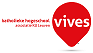<br>


**INTRODUCTION TO ARTIFICIAL INTELLIGENCE**<br>
Andy Louwyck<br>
Stefaan Haspeslagh

---



---



# SLIDING PUZZLE: DFS en BFS

In deze notebook tonen we hoe we een "sliding puzzle" (https://en.wikipedia.org/wiki/Sliding_puzzle) kunnen oplossen mbv de zoekalgoritmen **diepte-eerst en breedte-eerst**. Maar eerst definiëren we de klassen die we m.b.v. de state-space representation hebben bepaald.

## **Superklassen `State` en `Move`**

Belangrijke concepten zijn:
- toestand (Engels: state)
- doel (Engels: goal)
- zet (Engels: move)

We definiëren superklassen `State` en `Move` om deze concepten te implementeren.

Klasse `State`:
- methode `calculate_moves`: geeft de zetten die mogelijk zijn vanuit de huidige toestand door toepassen van de productieregels
- methode `apply_move`: past een zet toe op de huidige toestand waardoor we een nieuwe toestand krijgen
- methode `is_goal`: checkt of de huidige toestand een eindtoestand waarmee het doel is bereikt.
- We voegen ook methode `contains_loop` toe die checkt of de state een lus bevat.

In [ ]:
from abc import ABC, abstractmethod

class State(ABC):

    @abstractmethod
    def calculate_moves(self):
        # Op een state wordt deze methode aangeroepen om volgens de production rules
        # de moves te berekenen die het probleem in een nieuwe toestand kunnen brengen.
        # Deze functie geeft dus een lijst van moves terug (eventueel leeg).
        pass

    @abstractmethod
    def apply_move(self, move):
        # Op een state kan een move toegepast worden om naar een volgende state over te gaan.
        # Deze functie geeft dus een nieuwe state terug.
        pass
        
    @abstractmethod
    def is_goal(self):
        # Controleert of een state de `goal state` is.
        # Retourneert dus een booleaanse waarde.
        pass

    @abstractmethod
    def contains_loop(self):
        # Controleert of de state een lus bevat.
        # Retourneert dus een booleaanse waarde.
        pass

Klasse `Move`
- methode `apply`: past zichzelf (`self`) toe op een gegeven toestand (`state`) 

In [ ]:
class Move:
    def __init__(self, state):
        self.state = state
    def apply(self):
        return self.state.apply_move(self)

## **Subklassen `Puzzle` en `Slide`**

Bij de sliding puzzle:
- state: een bepaalde configuratie van de tegeltjes - hiervoor gebruiken we een NumPy array
- move: een tegeltje verschuiven
- goal: bereikt wanneer alle tegeltjes in de juiste volgorde liggen  

### Klasse `Slide`

- Zwarte vakje `(irow, icol)` naar links, rechts, omhoog of omlaag bewegen:
  - links: `icol_new = icol - 1`
  - rechts: `icol_new = icol + 1`
  - omhoog: `irow_new = irow - 1`
  - omlaag: `irow_new = irow + 1`
- Erft van superklasse `Move`

In [ ]:
import numpy as np

class Slide(Move):
    
    # constructor
    def __init__(self, state, drow=0, dcol=0):
        super().__init__(state)
        self.drow = drow
        self.dcol = dcol
    
    # checkt of slide geldig is, rekening houdend met de randen van de puzzle
    @abstractmethod
    def is_valid(self):
        pass
    
    # berekent de nieuwe positiematrix
    def new_matrix(self):
        if self.is_valid():
            irow1, icol1 = self.state.empty  # (irow, icol) van lege vakje
            irow2, icol2 = irow1 + self.drow, icol1 + self.dcol  # (irow, icol) van vakje waarmee gewisseld wordt
            new_matrix = self.state.matrix.copy()
            new_matrix[irow1,icol1], new_matrix[irow2,icol2] = new_matrix[irow2,icol2], new_matrix[irow1,icol1]
            return new_matrix    
    
    # string representatie object
    def __repr__(self):
        if self.dcol == -1:
            return 'L'
        elif self.dcol == 1:
            return 'R'
        elif self.drow == -1:
            return 'U'
        elif self.drow == 1:
            return 'D'

Subklassen creëren voor elke move afzonderlijk:

In [ ]:
class Left(Slide):
    def __init__(self, state):
        super().__init__(state, dcol=-1)
    def is_valid(self):
        return self.state.empty[1] > 0

class Right(Slide):
    def __init__(self, state):
        super().__init__(state, dcol=1)
    def is_valid(self):
        return self.state.empty[1] < self.state.size - 1

class Up(Slide):
    def __init__(self, state):
        super().__init__(state, drow=-1)
    def is_valid(self):
        return self.state.empty[0] > 0

class Down(Slide):
    def __init__(self, state):
        super().__init__(state, drow=1)    
    def is_valid(self):
        return self.state.empty[0] < self.state.size - 1

### Klasse `Puzzle`

- Klasse voor de toestand:
  - bevat de matrix met de positie van de tegeltjes
  - bevat ook de vorige toestanden (hoewel niet nodig om toestand te definiëren)
- Erft van superklasse `State`
- We voegen ook attribuut `rules` en setter `set_production_rules` toe zodat we de volgorde van de moves kunnen wijzigen
- We voegen ook property `full_path` die het volledige pad van de toestand geeft

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import clear_output
from time import sleep

class Puzzle(State):

    # constructor
    def __init__(self, matrix, previous=[]):
        self.matrix = np.array(matrix)  # matrix omzetten naar NumPy array
        self.size = len(matrix)  # aantal rijen = aantal kolommen
        self.empty = np.where(self.matrix == 0)  # (irow, icol) van lege vakje
        self.previous = previous  # vorige states
        self.rules = [Left(self), Right(self), Up(self), Down(self)]  # production rules
        
    # volledige pad
    @property
    def full_path(self):
        return self.previous + [self]
    
    # laat toe om de production rules te wijzigen
    def set_production_rules(self, *Slides):
        # Slides is input lijst met Slide klassen
        self.rules = [Slide(self) for Slide in Slides]
    
    # berekent de mogelijke posities van het zwarte vakje
    def calculate_moves(self):
        return [move for move in self.rules if move.is_valid()]
        
    # verschuift het zwarte vakje en retourneert nieuwe state
    def apply_move(self, move):
        new_puzzle = Puzzle(move.new_matrix(), self.full_path)  # nieuwe toestand
        Slides = [type(rule) for rule in self.rules]
        new_state.set_production_rules(*Slides)
        return new_puzzle
        
    # checkt of alle vakjes in de juiste volgorde liggen    
    def is_goal(self):
        goal = np.arange(1, self.size**2 + 1)
        goal[-1] = 0  # goal is de matrix met alle cijfers in de juiste volgorde (en nul op het einde)
        return np.all(self.matrix.flatten() == goal)

    def contains_loop(self):
        return self in self.previous
    
    # plot matrix    
    def plot(self):
        cmap = colors.ListedColormap(['black', 'lightblue'])
        norm = colors.BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
        grid = self.matrix.copy()
        grid[grid>0] = 1
        fig, ax = plt.subplots(1, 1)
        ax.matshow(grid, cmap=cmap, norm=norm)
        xx = np.arange(0, self.size)
        xx, yy = np.meshgrid(xx, xx)
        xx = xx.flatten()
        yy = yy.flatten()
        b = (grid > 0).flatten()
        matrix = self.matrix.flatten()
        font = dict(weight='bold', size=40)
        for x, y, i in zip(xx[b], yy[b], matrix[b]):
            ax.text(x, y, i, ha="center", va="center", fontdict=font)
        ax.set_aspect("equal")
        ticks = np.linspace(-0.5, self.size - 0.5, self.size + 1)
        ax.set_xticks(ticks)
        ax.set_xticklabels([])
        ax.set_yticks(ticks)
        ax.set_yticklabels([])
        ax.tick_params(axis=u'both', which=u'both', length=0)
        ax.grid(linewidth=3, color="white")
        ax.set_xlim((ticks[0], ticks[-1]))
        ax.set_ylim((ticks[-1], ticks[0]))
        plt.show()

    # plot opeenvolgende posities
    def plot_moves(self, wait=1):
        for puzzle in self.full_path:
            clear_output()
            puzzle.plot()
            sleep(wait)
          
    # omzetten naar string
    def __repr__(self):
        return "\n".join([" ".join(map(str, row)) for row in self.matrix]).replace("0", '.')

    # 2 objecten zijn gelijk als hun matrices gelijk zijn
    def __eq__(self, other):
        return np.all(self.matrix == other.matrix)

## **Klassendiagram**

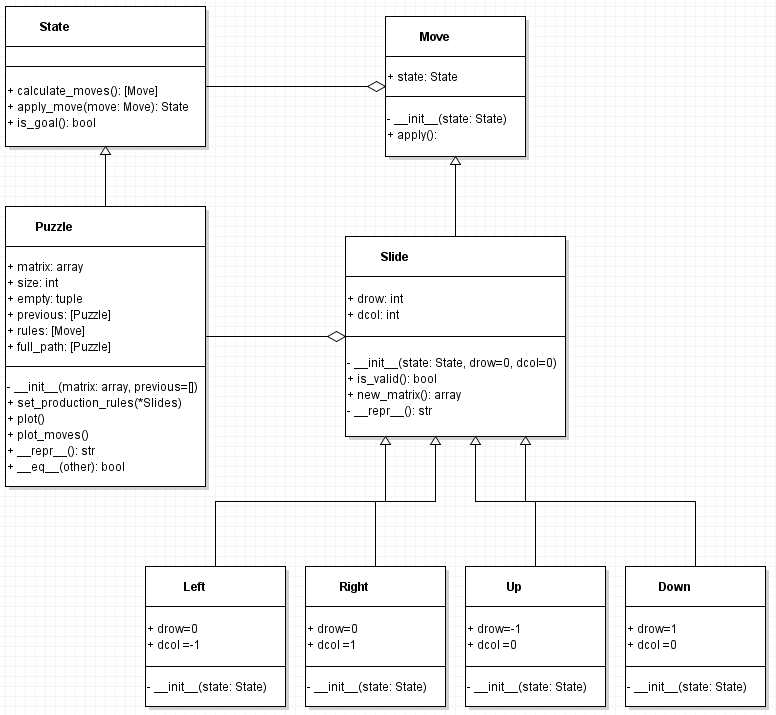

## **DFS en BFS**

### Blind search

Adhv de state representation en de productieregels kunnen we nu (impliciet) de **zoekboom** (Engels: search tree) opstellen om het doel te bereiken.

- De zoekboom bestaat uit **takken** (Engels: branches) en **knopen** (Engels: nodes).
- De begintoestand is de eerste knoop, de **root node**.
- Elke node komt overeen met het **pad** van de begintoestand naar een nieuwe toestand.
- We moeten één van de eindtoestanden bereiken die met ons doel overeenkomen, één van de **goal nodes**.
- De zoekboom kunnen we doorlopen met zoekalgoritmes:
 - we willen een pad vinden = **blind search**, bijvoorbeeld:
   - **diepte-eerst** (Engels: depth first search, DFS)
   - **breedte-eerst** (Engels: breadth first search, BFS)
 - we willen het kortste pad vinden = **heuristic search**
 - we willen het optimale pad vinden = **optimal search**


### DFS vs BFS

DFS en BFS verschillen slechts op één punt:
-  DFS = LIFO: 
    - nieuwe paden moeten *vooraan* de queue toegevoegd worden
    - vergelijk met stapel papieren (Engels: stack)
-  BFS = FIFO: 
    - nieuwe paden moeten *achteraan* de queue toegevoegd worden
    - vergelijk met wachtrij in winkel (Engels: queue)

Conclusie: we kunnen makkelijk één algoritme schrijven dat mbv een `if` statement de paden correct aan de queue toevoegt

0) IF (root is goal node): 
*  THEN: SUCCESS

1) QUEUE = path only containing the root

2) WHILE (QUEUE is not empty AND goal is not reached):

*  Remove the first path from the QUEUE;
*  Create new paths (to all children);
*  Reject the new paths with loops;
*  IF (**algorithm is DFS**): 
  - THEN: Add the new paths **to the front of QUEUE**

*  IF (**algorithm is BFS**):
  - THEN: Add the new paths **to the back of QUEUE**

3) IF (goal reached):

*  THEN: SUCCESS
*  ELSE: failure

### Functie `dfs_bfs`

We kunnen dus één functie `dfs_bfs` definiëren:
- inputparameters:
  - `ini_state` is een `Puzzle` object die de initiële toestand definieert
  - `method` is een string `'dfs'` of `'bfs`
- return value: 
  - Indien geen oplossing: `None`
  - Indien wel een oplossing: `Puzzle` object met de goal state

Merk op dat deze functie generiek is en dus onafhankelijk van ons sliding puzzle probleem!



In [ ]:
from time import time

def dfs_bfs(state, method):
# state is State object with initial state
# method is 'dfs' or 'bfs'

    # start time
    starttime = time()

    # 1. queue <- path only containing the root
    queue = [state]

    # initialize length queue
    length_queue = [1]

    # 2. while (queue is not empty and goal is not reached)
    goal_is_reached = state.is_goal()
    while queue and not goal_is_reached:

        # length queue
        length_queue.append(len(queue))
        
        # remove the first path from the queue
        first_state = queue.pop(0)

        # create new paths (to all children)
        new_states = [first_state.apply_move(move) for move in first_state.calculate_moves()]
        
        # reject the new paths with loops
        new_states = [new_state for new_state in new_states if not new_state.contains_loop()]

        # update goal_is_reached
        for state in new_states:
            if state.is_goal():
                goal_is_reached = True
                break 

        # if method is DFS: add the new paths to the FRONT of the queue
        if method.lower() == 'dfs':
            queue = new_states + queue
        # if method is BFS: add the new paths to the BACK of the queue
        elif method.lower() == 'bfs':
            queue = queue + new_states

    # 3. if (goal reached) then success else failure
    print("SUCCES" if goal_is_reached else "FAILURE")

    # print elapsed time
    print("Elapsted time:", time() - starttime, 'seconds')

    # print maximum length of queue
    print('Maximum length of queue:', max(length_queue))

    # return goal state if goal is reached and None otherwise
    return state if goal_is_reached else None

### Test

Eerst checken of de nieuwe methodes en functie `dfs_bfs` correct werken.

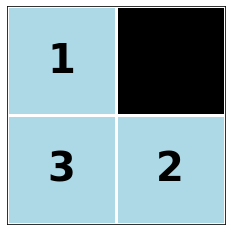

In [ ]:
matrix = [[1, 0], 
          [3, 2]]
puzzle = Puzzle(matrix)
puzzle.plot()

We printen het volledige pad uit adhv property `full_path` en checken of het een lus bevat met methode `contains_loop`:

In [ ]:
for p in puzzle.full_path:
    print(p)
    print()
print(p.contains_loop())

1 .
3 2

False


We berekenen de mogelijke moves:

In [ ]:
moves = puzzle.calculate_moves()
moves

[L, D]

We passen de laatste move toe, nl. het zwarte vakje naar onderen schuiven:

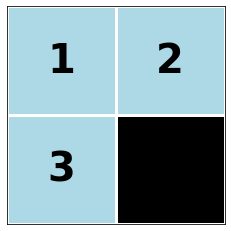

In [ ]:
new_puzzle = puzzle.apply_move(moves[-1])
new_puzzle.plot()

We checken opnieuw het volledige pad en kijken of dat lussen bevat:

In [ ]:
for p in new_puzzle.full_path:
    print(p)
    print()
print(new_puzzle.contains_loop())

1 .
3 2

1 2
3 .

False


Opnieuw de mogelijke zetten berekenen:

In [ ]:
moves = new_puzzle.calculate_moves()
moves

[L, U]

En de laatste zet toepassen:

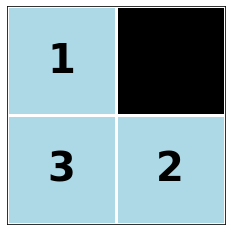

In [ ]:
new_puzzle = new_puzzle.apply_move(moves[-1])
new_puzzle.plot()

We zijn teruggekeerd naar de initiële configuratie, dus het pad bevat een lus:

In [ ]:
for p in new_puzzle.full_path:
    print(p)
    print()
print(new_puzzle.contains_loop())

1 .
3 2

1 2
3 .

1 .
3 2

True


We passen DFS toe op de initiële puzzle:

In [ ]:
solution = dfs_bfs(puzzle, 'dfs')

SUCCES
Elapsted time: 0.0010614395141601562 seconds
Maximum length of queue: 1


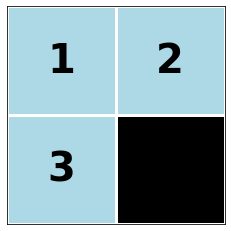

In [ ]:
solution.plot_moves()

En we passen BFS toe:

In [ ]:
solution = dfs_bfs(puzzle, 'bfs')

SUCCES
Elapsted time: 0.0008721351623535156 seconds
Maximum length of queue: 1


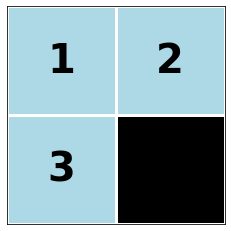

In [ ]:
solution.plot_moves()

## **Voorbeelden**

We definiëren eerst een functie `print_solution` die de moves uitprint:

In [ ]:
def print_solution(solution):
    if not solution:
        print("no solution...")
    else:
        for puzzle in solution.full_path:
            print(puzzle)
            print()
        print("number of moves:", len(solution.full_path))

### 3-puzzle

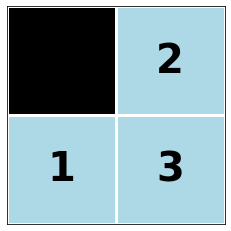

In [ ]:
puzzle1 = Puzzle(matrix=[[0, 2], [1, 3]])
puzzle1.plot()

DFS:

In [ ]:
solution = dfs_bfs(puzzle1, "DFS")

SUCCES
Elapsted time: 0.003299236297607422 seconds
Maximum length of queue: 2


In [ ]:
print_solution(solution)

. 2
1 3

2 .
1 3

2 3
1 .

2 3
. 1

. 3
2 1

3 .
2 1

3 1
2 .

3 1
. 2

. 1
3 2

1 .
3 2

1 2
3 .

number of moves: 11


BFS:

In [ ]:
solution = dfs_bfs(puzzle1, "BFS")

SUCCES
Elapsted time: 0.0024793148040771484 seconds
Maximum length of queue: 2


In [ ]:
print_solution(solution)

. 2
1 3

1 2
. 3

1 2
3 .

number of moves: 3


DFS en BFS komen zelfs in dit eenvoudige voorbeeld niet tot een zelfde oplossing. We weten wel dat BFS de oplossing vindt met het minst aantal nodige moves.  


Wat als de tegeltjes al in de juiste volgorde liggen?

In [ ]:
puzzle2 = Puzzle(matrix=[[1, 2], [3, 0]])  # doel is al bereikt!
print_solution(dfs_bfs(puzzle2, "DFS"))

SUCCES
Elapsted time: 0.00010991096496582031 seconds
Maximum length of queue: 1
1 2
3 .

number of moves: 1


Soms vinden DFS en BFS wel hetzelfde pad:

In [ ]:
puzzle3 = Puzzle([[2, 3], [0, 1]])
solution = dfs_bfs(puzzle3, "DFS")
print()
print_solution(solution)

SUCCES
Elapsted time: 0.006710529327392578 seconds
Maximum length of queue: 2

2 3
. 1

2 3
1 .

2 .
1 3

. 2
1 3

1 2
. 3

1 2
3 .

number of moves: 6


In [ ]:
solution = dfs_bfs(puzzle3, "DFS")
print()
print_solution(solution)

SUCCES
Elapsted time: 0.0030143260955810547 seconds
Maximum length of queue: 2

2 3
. 1

2 3
1 .

2 .
1 3

. 2
1 3

1 2
. 3

1 2
3 .

number of moves: 6


Maar niet alle begintoestanden leiden tot een oplossing...

In [ ]:
puzzle4 = Puzzle([[1, 3], [0, 2]])
solution = dfs_bfs(puzzle4, "BFS")

FAILURE
Elapsted time: 0.007417917251586914 seconds
Maximum length of queue: 2


### 8-puzzle

Bij een puzzle met 9 vakjes zijn er 9! = 9 x 8 x ... x 2 startposities mogelijk, waarvan de helft tot een oplossing leidt.

In [ ]:
puzzle1 = Puzzle([[1, 2, 3], [4, 0, 5], [7, 8, 6]])
solution = dfs_bfs(puzzle1, "DFS")
print()
print_solution(solution)

SUCCES
Elapsted time: 0.014553070068359375 seconds
Maximum length of queue: 26

1 2 3
4 . 5
7 8 6

1 2 3
. 4 5
7 8 6

. 2 3
1 4 5
7 8 6

2 . 3
1 4 5
7 8 6

2 3 .
1 4 5
7 8 6

2 3 5
1 4 .
7 8 6

2 3 5
1 . 4
7 8 6

2 3 5
. 1 4
7 8 6

. 3 5
2 1 4
7 8 6

3 . 5
2 1 4
7 8 6

3 5 .
2 1 4
7 8 6

3 5 4
2 1 .
7 8 6

3 5 4
2 . 1
7 8 6

3 5 4
. 2 1
7 8 6

. 5 4
3 2 1
7 8 6

5 . 4
3 2 1
7 8 6

5 4 .
3 2 1
7 8 6

5 4 1
3 2 .
7 8 6

5 4 1
3 . 2
7 8 6

5 4 1
. 3 2
7 8 6

. 4 1
5 3 2
7 8 6

4 . 1
5 3 2
7 8 6

4 1 .
5 3 2
7 8 6

4 1 2
5 3 .
7 8 6

4 1 2
5 . 3
7 8 6

4 1 2
. 5 3
7 8 6

. 1 2
4 5 3
7 8 6

1 . 2
4 5 3
7 8 6

1 2 .
4 5 3
7 8 6

1 2 3
4 5 .
7 8 6

1 2 3
4 5 6
7 8 .

number of moves: 31


BFS vindt wel het kortste pad. Is dat altijd zo?

In [ ]:
solution = dfs_bfs(puzzle1, "BFS")
print()
print_solution(solution)

SUCCES
Elapsted time: 0.0033941268920898438 seconds
Maximum length of queue: 5

1 2 3
4 . 5
7 8 6

1 2 3
4 5 .
7 8 6

1 2 3
4 5 6
7 8 .

number of moves: 3


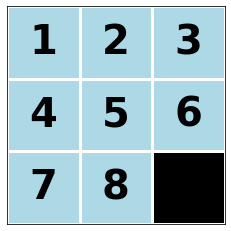

In [ ]:
solution.plot_moves()

In het volgende voorbeeld vinden ze wel beiden het korste pad:

In [ ]:
puzzle2 = Puzzle([[2, 0, 3], [1, 4, 5], [7, 8, 6]])
solution = dfs_bfs(puzzle2, "DFS")
print()
print_solution(solution)

SUCCES
Elapsted time: 0.005323171615600586 seconds
Maximum length of queue: 6

2 . 3
1 4 5
7 8 6

. 2 3
1 4 5
7 8 6

1 2 3
. 4 5
7 8 6

1 2 3
4 . 5
7 8 6

1 2 3
4 5 .
7 8 6

1 2 3
4 5 6
7 8 .

number of moves: 6


In [ ]:
solution = dfs_bfs(puzzle2, "BFS")
print()
print_solution(solution)

SUCCES
Elapsted time: 0.008855342864990234 seconds
Maximum length of queue: 14

2 . 3
1 4 5
7 8 6

. 2 3
1 4 5
7 8 6

1 2 3
. 4 5
7 8 6

1 2 3
4 . 5
7 8 6

1 2 3
4 5 .
7 8 6

1 2 3
4 5 6
7 8 .

number of moves: 6


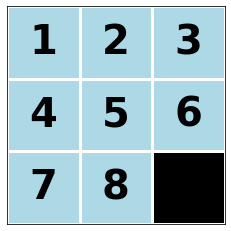

In [ ]:
solution.plot_moves()

## **Opdracht**

Speel zelf eens met andere begintoestanden en met grotere speelborden (bv. 4 op 4 of 5 op 5). 

Hoe komt het dat je niet altijd een oplossing vindt? En waarom duurt het soms zeer lang?

Soms crasht Colab omdat er te weinig RAM is... Hoe komt dat? Zou je dat kunnen oplossen?